# Retail Sales and Demand Analysis with Sales Prediction

## IBM SkillsBuild Data Analytics with AI Internship Project

### Problem Statement

Retail businesses generate large amounts of sales data every day. However, simply storing sales data is not enough. Businesses need to understand sales patterns, identify products with high and low demand, analyze the factors affecting sales, and estimate future demand.

This project aims to analyze historical retail sales data using data analytics and machine learning techniques. The project will clean and preprocess the sales data, perform exploratory data analysis, identify important sales patterns, predict future product demand, and generate action-oriented recommendations to support inventory and sales decisions.

### Main Objective

To develop a data analytics and AI-based system that analyzes historical retail sales and predicts future demand so that businesses can make better inventory and sales decisions.

## Project Objectives

1. Collect and understand historical retail sales data.
2. Clean and preprocess the sales data.
3. Analyze sales trends and product demand.
4. Identify high-demand and low-demand products.
5. Study factors that influence sales.
6. Create useful visualizations to understand sales patterns.
7. Prepare the data for machine learning.
8. Build a machine learning model to predict future sales/demand.
9. Evaluate the prediction model using suitable metrics.
10. Generate action-oriented recommendations for inventory and sales planning.

## Dataset Description

The dataset contains historical retail sales information.

The dataset will be used to study:
- Sales performance
- Product demand
- Sales trends
- High-demand and low-demand products
- Factors affecting sales
- Future sales/demand

### Dataset Information

The following information will be identified after loading the dataset:

- Number of rows
- Number of columns
- Column names
- Data types
- Missing values
- Duplicate records
- Numerical and categorical features

In [3]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [9]:
# Load the dataset

df = pd.read_csv("Sales_transactions_2022_2025.csv")

# Display the first 5 rows
df.head()

,Transaction_ID,Order_ID,Customer_ID,Customer_Name,Customer_Age,Customer_Gender,Customer_Segment,Order_Date,Order_Time,Sales_Channel,...,Order_Status,Shipping_Method,Delivery_Days,Return_Flag,Return_Reason,Sales_Representative,Promotion_Code,Customer_Rating,Inventory_Level,Order_Year
0,T02016694,O0116694,C01482,Sophia Smith,28.0,Male,Consumer,2022-10-06,11:30:55,Online,...,Completed,Standard,4.0,No,NaN,James Anderson,SAVE10,4.0,81.0,2022
1,T02016374,O0108187,C01591,Hannah King,46.0,Female,Consumer,2024-06-03,17:06:29,Online,...,Completed,Standard,6.0,No,NaN,Ella Lewis,NaN,5.0,123.0,2024
2,T02004099,O0104099,C04140,Emma Wilson,42.0,Male,Consumer,2024-12-19,08:22:11,Online,...,Shipped,Standard,4.0,No,NaN,Liam Davis,NaN,4.0,93.0,2024
3,T02010280,O0110280,C03663,Daniel Clark,18.0,Male,Corporate,2025-10-05,14:32:43,B2B Portal,...,Completed,Next Day,2.0,No,NaN,Grace Harris,HOLIDAY20,NaN,59.0,2025
4,T02012685,O0112685,C02749,Sophia Smith,37.0,Male,Returning Customer,2022-09-13,14:55:16,B2B Portal,...,Completed,Express,2.0,No,NaN,Sophia Brown,NaN,2.0,56.0,2022


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18045 entries, 0 to 18044
Data columns (total 36 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Transaction_ID        18045 non-null  str    
 1   Order_ID              18045 non-null  str    
 2   Customer_ID           18045 non-null  str    
 3   Customer_Name         17937 non-null  str    
 4   Customer_Age          17827 non-null  float64
 5   Customer_Gender       17883 non-null  str    
 6   Customer_Segment      18045 non-null  str    
 7   Order_Date            18045 non-null  str    
 8   Order_Time            18045 non-null  str    
 9   Sales_Channel         18045 non-null  str    
 10  Store_ID              18045 non-null  str    
 11  Store_Name            18045 non-null  str    
 12  Country               18045 non-null  str    
 13  Region                18045 non-null  str    
 14  City                  18045 non-null  str    
 15  Product_ID            18045 no

In [11]:
df.isnull().sum()

Transaction_ID              0
Order_ID                    0
Customer_ID                 0
Customer_Name             108
Customer_Age              218
Customer_Gender           162
Customer_Segment            0
Order_Date                  0
Order_Time                  0
Sales_Channel               0
Store_ID                    0
Store_Name                  0
Country                     0
Region                      0
City                        0
Product_ID                  0
Product_Name              144
Product_Category            0
Product_Subcategory         0
Quantity                    0
Unit_Price                  0
Discount_Percentage         0
Sales_Amount                0
Cost_Amount                 0
Profit                      0
Payment_Method            147
Order_Status                0
Shipping_Method             0
Delivery_Days             162
Return_Flag                 0
Return_Reason           16168
Sales_Representative        0
Promotion_Code           9737
Customer_R

In [12]:
# Handle missing values

# Fill text columns with "Unknown"
text_columns = [
    "Customer_Name",
    "Customer_Gender",
    "Product_Name",
    "Payment_Method",
    "Return_Reason",
    "Promotion_Code"
]

for col in text_columns:
    df[col] = df[col].fillna("Unknown")

# Fill numerical columns with their median
numeric_columns = [
    "Customer_Age",
    "Delivery_Days",
    "Customer_Rating",
    "Inventory_Level"
]

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

print("Missing values handled successfully!")

Missing values handled successfully!


In [13]:
df.isnull().sum()

Transaction_ID          0
Order_ID                0
Customer_ID             0
Customer_Name           0
Customer_Age            0
Customer_Gender         0
Customer_Segment        0
Order_Date              0
Order_Time              0
Sales_Channel           0
Store_ID                0
Store_Name              0
Country                 0
Region                  0
City                    0
Product_ID              0
Product_Name            0
Product_Category        0
Product_Subcategory     0
Quantity                0
Unit_Price              0
Discount_Percentage     0
Sales_Amount            0
Cost_Amount             0
Profit                  0
Payment_Method          0
Order_Status            0
Shipping_Method         0
Delivery_Days           0
Return_Flag             0
Return_Reason           0
Sales_Representative    0
Promotion_Code          0
Customer_Rating         0
Inventory_Level         0
Order_Year              0
dtype: int64

In [14]:
print("Number of rows:",df.shape[0])
print("Number of columns:",df.shape[1])

Number of rows: 18045
Number of columns: 36


In [15]:
# Display all column names

for i, column in enumerate(df.columns, start=1):
    print(i, column)

1 Transaction_ID
2 Order_ID
3 Customer_ID
4 Customer_Name
5 Customer_Age
6 Customer_Gender
7 Customer_Segment
8 Order_Date
9 Order_Time
10 Sales_Channel
11 Store_ID
12 Store_Name
13 Country
14 Region
15 City
16 Product_ID
17 Product_Name
18 Product_Category
19 Product_Subcategory
20 Quantity
21 Unit_Price
22 Discount_Percentage
23 Sales_Amount
24 Cost_Amount
25 Profit
26 Payment_Method
27 Order_Status
28 Shipping_Method
29 Delivery_Days
30 Return_Flag
31 Return_Reason
32 Sales_Representative
33 Promotion_Code
34 Customer_Rating
35 Inventory_Level
36 Order_Year


In [16]:
df.describe()

,Customer_Age,Quantity,Unit_Price,Discount_Percentage,Sales_Amount,Cost_Amount,Profit,Delivery_Days,Customer_Rating,Inventory_Level,Order_Year
count,18045.000000,18045.000000,18045.000000,18045.000000,18045.000000,18045.000000,18045.000000,18045.000000,18045.000000,18045.000000,18045.000000
mean,38.917927,2.127127,232.685633,6.256858,457.309027,366.001156,91.404131,2.250873,3.988640,70.255085,2023.566417
std,10.662362,1.786212,294.208022,6.881178,856.597181,705.866738,167.827883,2.314275,0.907391,21.921353,1.118744
min,4.000000,-3.000000,21.390000,0.000000,16.680000,12.170000,-299.310000,0.000000,1.000000,0.000000,2022.000000
25%,32.000000,1.000000,53.380000,0.000000,78.530000,56.120000,19.480000,0.000000,4.000000,56.000000,2023.000000
50%,39.000000,2.000000,99.870000,5.000000,168.810000,122.300000,40.190000,1.000000,4.000000,70.000000,2024.000000
75%,46.000000,3.000000,285.580000,10.000000,472.450000,376.020000,93.270000,4.000000,5.000000,85.000000,2025.000000
max,112.000000,11.000000,1425.090000,110.000000,14303.070000,10791.000000,3512.080000,10.000000,5.000000,157.000000,2025.000000


In [17]:
# Check unusual values

print("Negative Quantity:")
print(df[df["Quantity"] < 0][["Transaction_ID", "Quantity", "Sales_Amount", "Profit"]])

print("\nAge above 100:")
print(df[df["Customer_Age"] > 100][["Transaction_ID", "Customer_Age"]])

print("\nDiscount above 100%:")
print(df[df["Discount_Percentage"] > 100][["Transaction_ID", "Discount_Percentage"]])

Negative Quantity:
      Transaction_ID  Quantity  Sales_Amount  Profit
3986       T02006553        -2        273.09   17.16
7487       T02011209        -1        460.31   89.12
12156      T02004207        -3        868.21  140.35

Age above 100:
     Transaction_ID  Customer_Age
1851      T02003795         112.0

Discount above 100%:
      Transaction_ID  Discount_Percentage
17278      T02015278                110.0


In [3]:
import pandas as pd

In [4]:
df=pd.read_csv("Sales_transactions_2022_2025.csv")

In [5]:
print(df.shape)

(18045, 36)


In [6]:
# Inspect the unusual transactions

unusual_ids = [
    "T02006553",
    "T02011209",
    "T02004207",
    "T02003795",
    "T02015278"
]

df[df["Transaction_ID"].isin(unusual_ids)]

,Transaction_ID,Order_ID,Customer_ID,Customer_Name,Customer_Age,Customer_Gender,Customer_Segment,Order_Date,Order_Time,Sales_Channel,...,Order_Status,Shipping_Method,Delivery_Days,Return_Flag,Return_Reason,Sales_Representative,Promotion_Code,Customer_Rating,Inventory_Level,Order_Year
1851,T02003795,O0101897,C02947,Alexander Williams,112.0,Female,Consumer,2025-06-30,12:39:52,Retail Store,...,Cancelled,Standard,2.0,No,NaN,Amelia Jackson,BLACKFRIDAY25,5.0,57.0,2025
3986,T02006553,O0103276,C04087,Theo Green,31.0,Female,Consumer,2025-11-29,09:25:49,Online,...,Shipped,Standard,6.0,No,NaN,Grace Harris,HOLIDAY20,5.0,102.0,2025
7487,T02011209,O0111209,C00483,Benjamin Wilson,30.0,Female,Small Business,2025-02-02,11:39:22,Online,...,Processing,Standard,4.0,No,NaN,David Walker,NaN,4.0,68.0,2025
12156,T02004207,O0104207,C02953,William White,48.0,Male,Corporate,2022-01-04,21:23:13,Online,...,Completed,Standard,4.0,No,NaN,Sophia Brown,SUMMER10,5.0,104.0,2022
17278,T02015278,O0115278,C02934,Lily Hall,22.0,Female,Returning Customer,2024-05-08,16:57:11,Retail Store,...,Returned,Standard,6.0,Yes,Other,Mia Taylor,SPRING15,4.0,111.0,2024


In [7]:
# Handle missing values again

text_columns = [
    "Customer_Name",
    "Customer_Gender",
    "Product_Name",
    "Payment_Method",
    "Return_Reason",
    "Promotion_Code"
]

for col in text_columns:
    df[col] = df[col].fillna("Unknown")

numeric_columns = [
    "Customer_Age",
    "Delivery_Days",
    "Customer_Rating",
    "Inventory_Level"
]

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

print("Dataset cleaned successfully!")

Dataset cleaned successfully!


In [11]:
import matplotlib.pyplot as plt

Order_Year
2022    2013101.54
2023    2024151.87
2024    1913628.53
2025    2301259.46
Name: Sales_Amount, dtype: float64


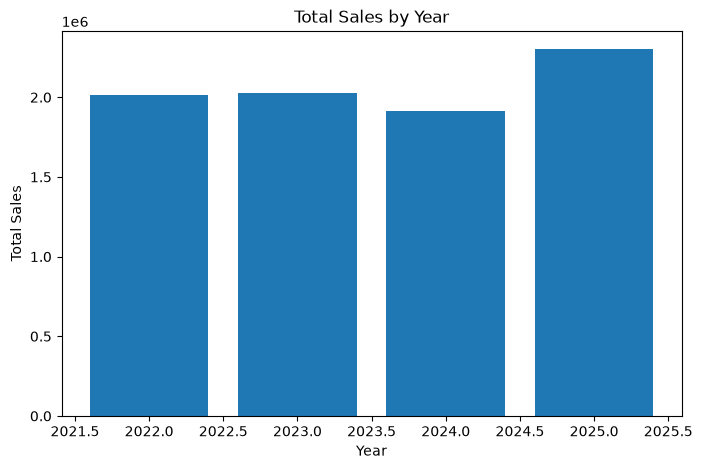

In [12]:
# Sales by Year

sales_by_year = df.groupby("Order_Year")["Sales_Amount"].sum()

print(sales_by_year)

# Create the graph
plt.figure(figsize=(8, 5))

plt.bar(sales_by_year.index, sales_by_year.values)

plt.title("Total Sales by Year")
plt.xlabel("Year")
plt.ylabel("Total Sales")

plt.show()

Order_Year
2022    407575.25
2023    401809.69
2024    384807.48
2025    455195.12
Name: Profit, dtype: float64


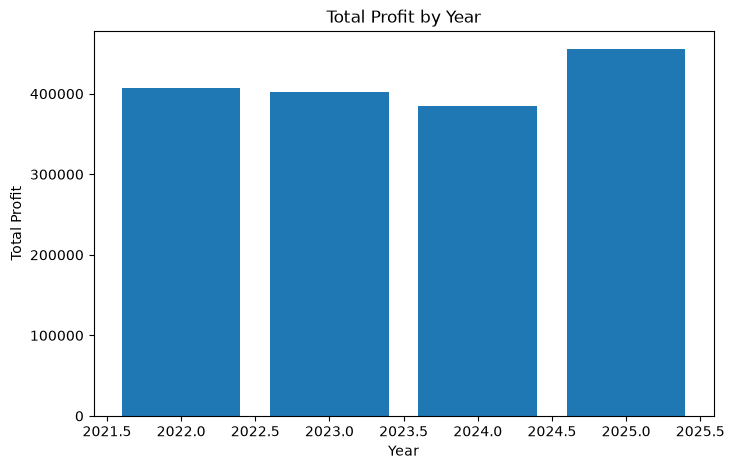

In [13]:
# Profit by Year

profit_by_year = df.groupby("Order_Year")["Profit"].sum()

print(profit_by_year)

# Create the graph
plt.figure(figsize=(8, 5))

plt.bar(profit_by_year.index, profit_by_year.values)

plt.title("Total Profit by Year")
plt.xlabel("Year")
plt.ylabel("Total Profit")

plt.show()

Product_Category
Electronics        4896217.10
Furniture          1972093.54
Office Supplies     740413.66
Appliances          585096.67
electronics          35928.37
FURNITURE            17765.70
Office supplies       4626.36
Name: Sales_Amount, dtype: float64


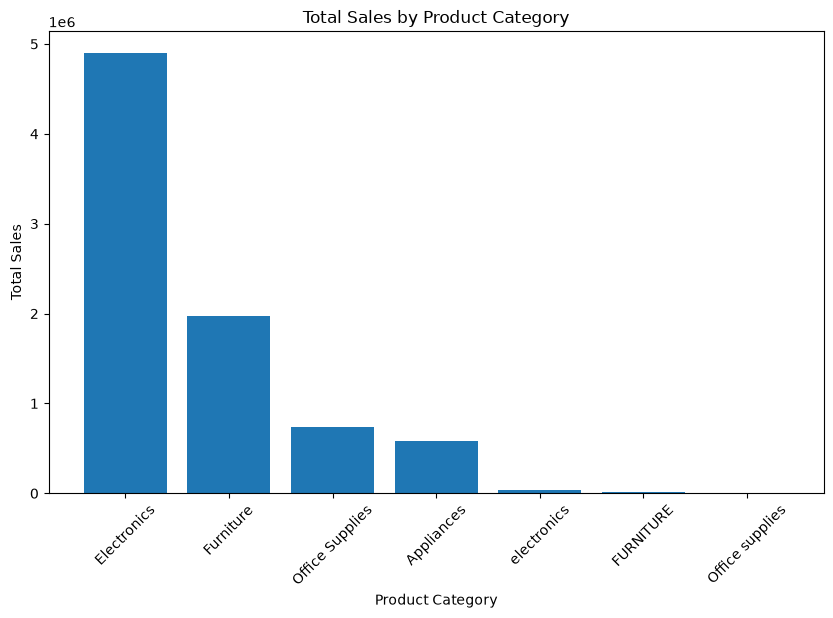

In [14]:
# Sales by Product Category

sales_by_category = df.groupby("Product_Category")["Sales_Amount"].sum().sort_values(ascending=False)

print(sales_by_category)

# Create the graph
plt.figure(figsize=(10, 6))

plt.bar(sales_by_category.index, sales_by_category.values)

plt.title("Total Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.show()

Product_Category
Electronics        946807.76
Furniture          417279.40
Office Supplies    144060.75
Appliances         128750.75
electronics          7631.80
FURNITURE            3794.57
Office supplies      1062.51
Name: Profit, dtype: float64


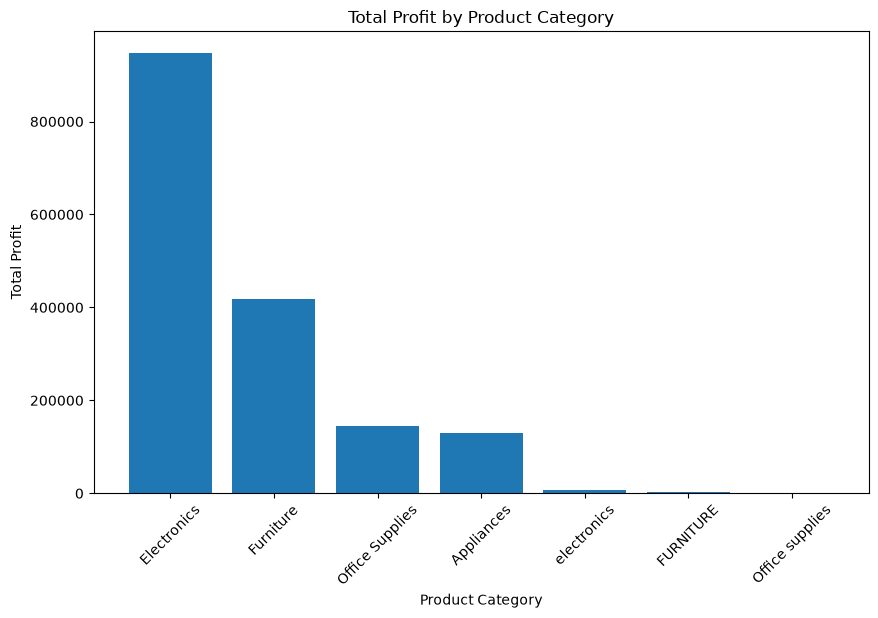

In [15]:
# Profit by Product Category

profit_by_category = df.groupby("Product_Category")["Profit"].sum().sort_values(ascending=False)

print(profit_by_category)

# Create the graph
plt.figure(figsize=(10, 6))

plt.bar(profit_by_category.index, profit_by_category.values)

plt.title("Total Profit by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Profit")

plt.xticks(rotation=45)

plt.show()

Sales_Channel
Online          3118241.65
Retail Store    2452712.71
B2B Portal      2128281.04
Phone Order      552906.00
Name: Sales_Amount, dtype: float64


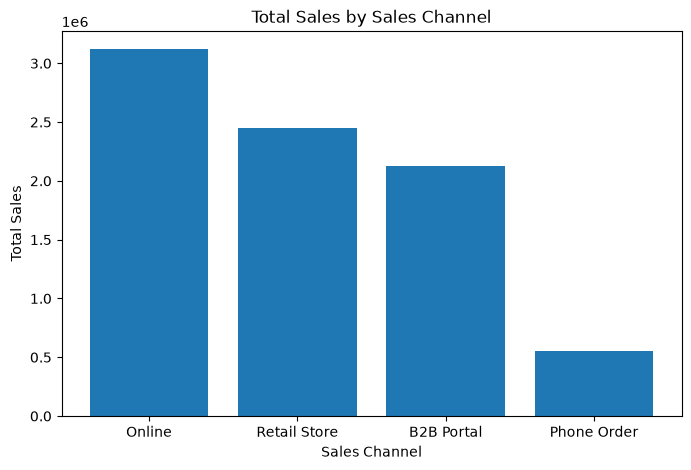

In [16]:
# Sales by Sales Channel

sales_by_channel = df.groupby("Sales_Channel")["Sales_Amount"].sum().sort_values(ascending=False)

print(sales_by_channel)

# Create the graph
plt.figure(figsize=(8, 5))

plt.bar(sales_by_channel.index, sales_by_channel.values)

plt.title("Total Sales by Sales Channel")
plt.xlabel("Sales Channel")
plt.ylabel("Total Sales")

plt.show()

Customer_Segment
Consumer              3672813.49
Small Business        1424579.90
Returning Customer    1117471.10
Corporate              947034.82
New Customer           709567.01
Premium                380675.08
Name: Sales_Amount, dtype: float64


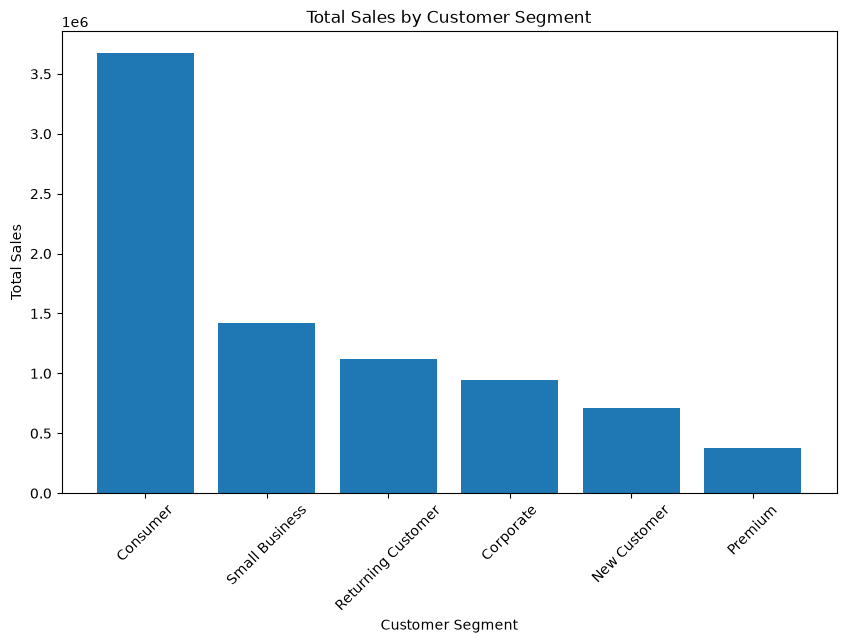

In [17]:
# Sales by Customer Segment

sales_by_segment = df.groupby("Customer_Segment")["Sales_Amount"].sum().sort_values(ascending=False)

print(sales_by_segment)

# Create the graph
plt.figure(figsize=(10, 6))

plt.bar(sales_by_segment.index, sales_by_segment.values)

plt.title("Total Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.show()

Product_Name
AeroBook 14 Laptop    1382381.54
ProBook 16 Laptop     1350069.32
EdgeTab 11 Tablet      675690.83
Standing Desk          590085.65
Meeting Table          530253.01
Vision 27 Monitor      459316.26
Office Chair Pro       437914.82
Printer Plus           257377.58
Air Purifier           237203.24
Filing Cabinet         222637.74
Name: Sales_Amount, dtype: float64


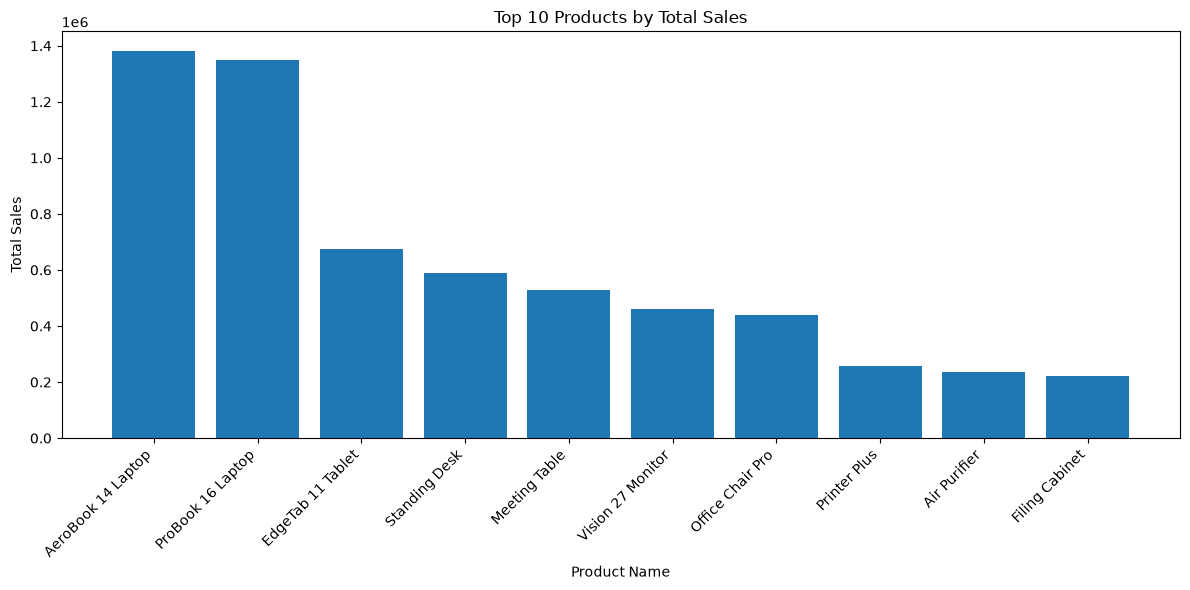

In [18]:
# Top 10 Products by Sales

top_products = (
    df.groupby("Product_Name")["Sales_Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

# Create the graph
plt.figure(figsize=(12, 6))

plt.bar(top_products.index, top_products.values)

plt.title("Top 10 Products by Total Sales")
plt.xlabel("Product Name")
plt.ylabel("Total Sales")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

Product_Name
ProBook 16 Laptop      252332.94
AeroBook 14 Laptop     234632.00
Standing Desk          118917.87
EdgeTab 11 Tablet      100538.15
Office Chair Pro        96030.81
Vision 27 Monitor       90685.79
Meeting Table           82509.73
NoiseCancel Headset     55546.13
Filing Cabinet          55425.35
Air Purifier            51251.63
Name: Profit, dtype: float64


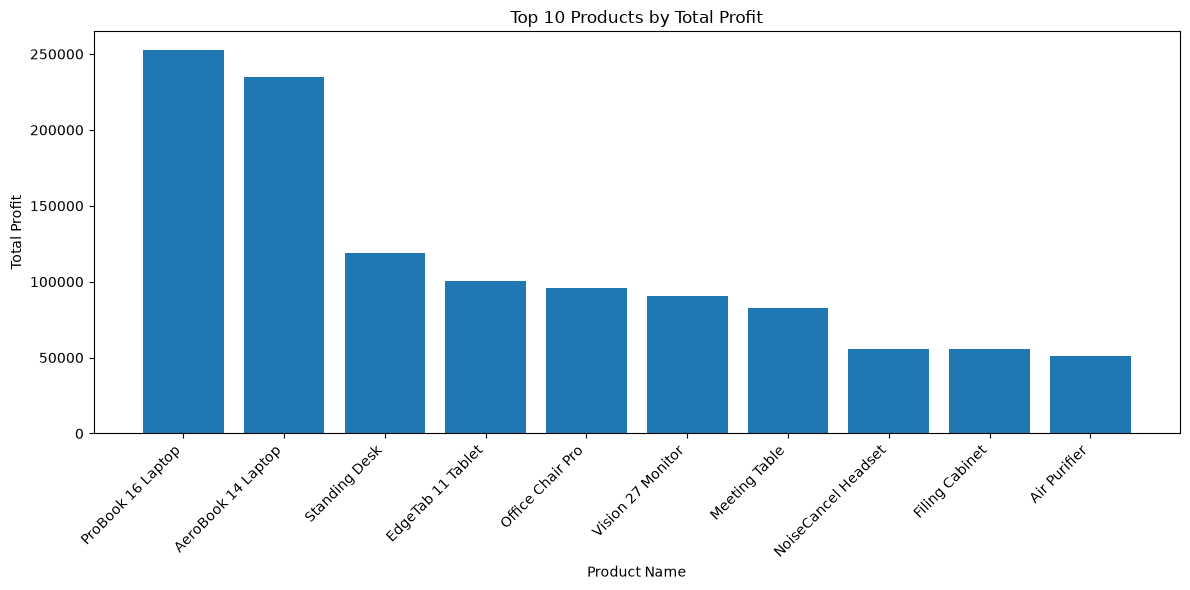

In [19]:
# Top 10 Products by Profit

top_profit_products = (
    df.groupby("Product_Name")["Profit"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_profit_products)

# Create the graph
plt.figure(figsize=(12, 6))

plt.bar(top_profit_products.index, top_profit_products.values)

plt.title("Top 10 Products by Total Profit")
plt.xlabel("Product Name")
plt.ylabel("Total Profit")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [20]:
# Convert Order_Date to date format

df["Order_Date"] = pd.to_datetime(df["Order_Date"])

# Create a Month column
df["Month"] = df["Order_Date"].dt.month

# Calculate sales by month
monthly_sales = (
    df.groupby("Month")["Sales_Amount"]
    .sum()
)

print(monthly_sales)

Month
1     497162.10
2     500449.38
3     715359.91
4     660076.59
5     710793.91
6     583347.50
7     619564.10
8     643259.68
9     620723.73
10    831860.56
11    918588.81
12    950955.13
Name: Sales_Amount, dtype: float64


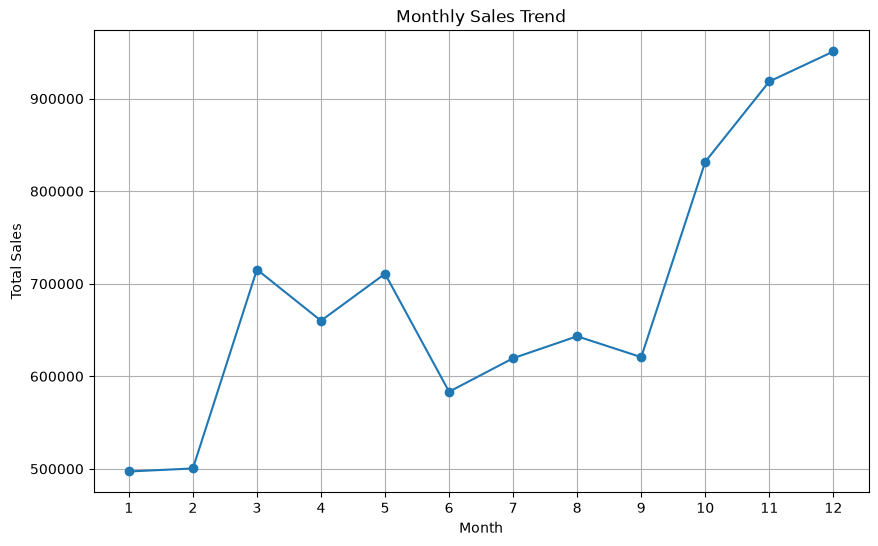

In [21]:
# Monthly Sales Graph

plt.figure(figsize=(10, 6))

plt.plot(monthly_sales.index, monthly_sales.values, marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(range(1, 13))

plt.grid(True)

plt.show()

In [22]:
# Calculate profit by month

monthly_profit = (
    df.groupby("Month")["Profit"]
    .sum()
)

print(monthly_profit)

Month
1     111875.96
2      91379.02
3     162870.03
4     149629.84
5     129223.05
6     134298.77
7     141948.86
8     147582.18
9     146051.35
10    187386.90
11    120280.30
12    126861.28
Name: Profit, dtype: float64


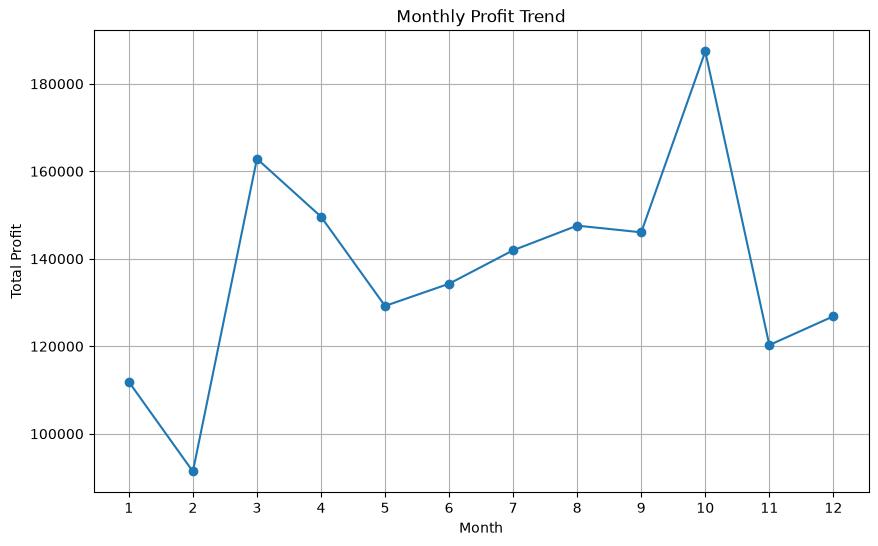

In [23]:
# Monthly Profit Graph

plt.figure(figsize=(10, 6))

plt.plot(monthly_profit.index, monthly_profit.values, marker="o")

plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Total Profit")

plt.xticks(range(1, 13))

plt.grid(True)

plt.show()

Payment_Method
Credit Card      3196492.28
Debit Card       1718030.84
PayPal           1320696.64
Bank Transfer     924114.91
Cash              471629.64
Apple Pay         466821.63
credit card        64809.46
Unknown            46546.17
DebitCard          24245.00
paypal             10339.10
Bank transfer       8415.73
Name: Sales_Amount, dtype: float64


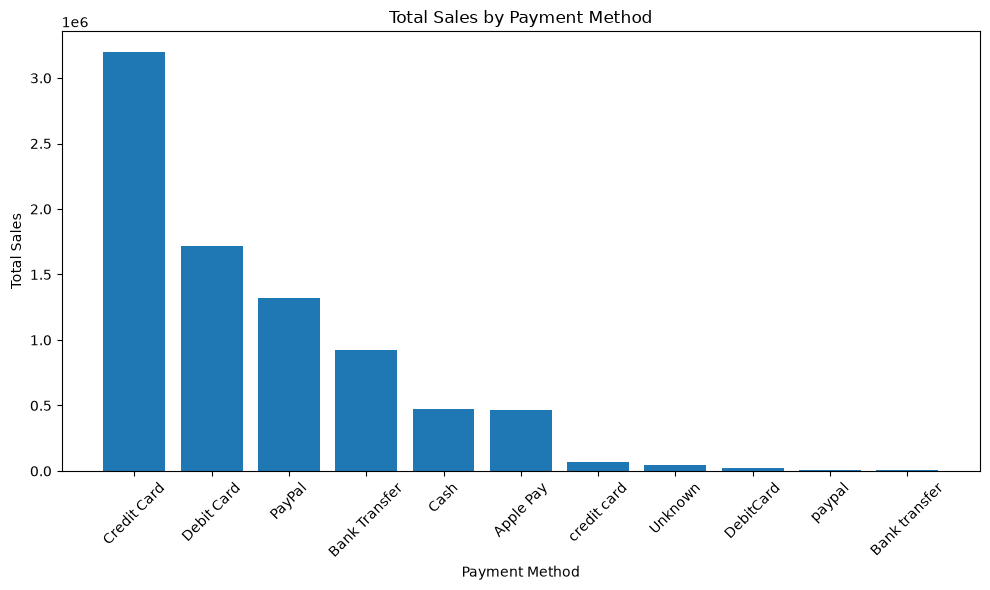

In [24]:
# Sales by Payment Method

sales_by_payment = (
    df.groupby("Payment_Method")["Sales_Amount"]
    .sum()
    .sort_values(ascending=False)
)

print(sales_by_payment)

# Create the graph
plt.figure(figsize=(10, 6))

plt.bar(sales_by_payment.index, sales_by_payment.values)

plt.title("Total Sales by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [25]:
# Count returned and non-returned transactions

return_counts = df["Return_Flag"].value_counts()

print(return_counts)

Return_Flag
No     16168
Yes     1877
Name: count, dtype: int64


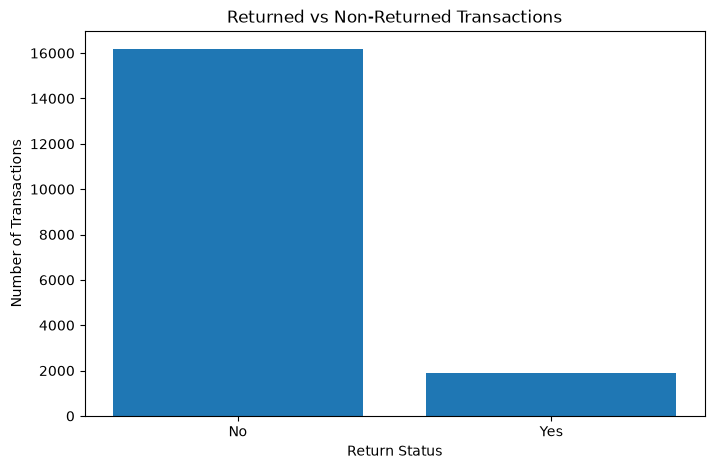

In [26]:
# Return Status Graph

plt.figure(figsize=(8, 5))

plt.bar(return_counts.index, return_counts.values)

plt.title("Returned vs Non-Returned Transactions")
plt.xlabel("Return Status")
plt.ylabel("Number of Transactions")

plt.show()

In [27]:
# Calculate Return Rate

total_transactions = len(df)

returned_transactions = (df["Return_Flag"] == "Yes").sum()

return_rate = (returned_transactions / total_transactions) * 100

print("Total Transactions:", total_transactions)
print("Returned Transactions:", returned_transactions)
print("Return Rate: {:.2f}%".format(return_rate))

Total Transactions: 18045
Returned Transactions: 1877
Return Rate: 10.40%


In [28]:
# Analyze return reasons

return_reasons = (
    df[df["Return_Flag"] == "Yes"]["Return_Reason"]
    .value_counts()
)

print(return_reasons)

Return_Reason
Late Delivery    331
Wrong Item       320
Damaged          312
Other            312
Defective        302
Changed Mind     300
Name: count, dtype: int64


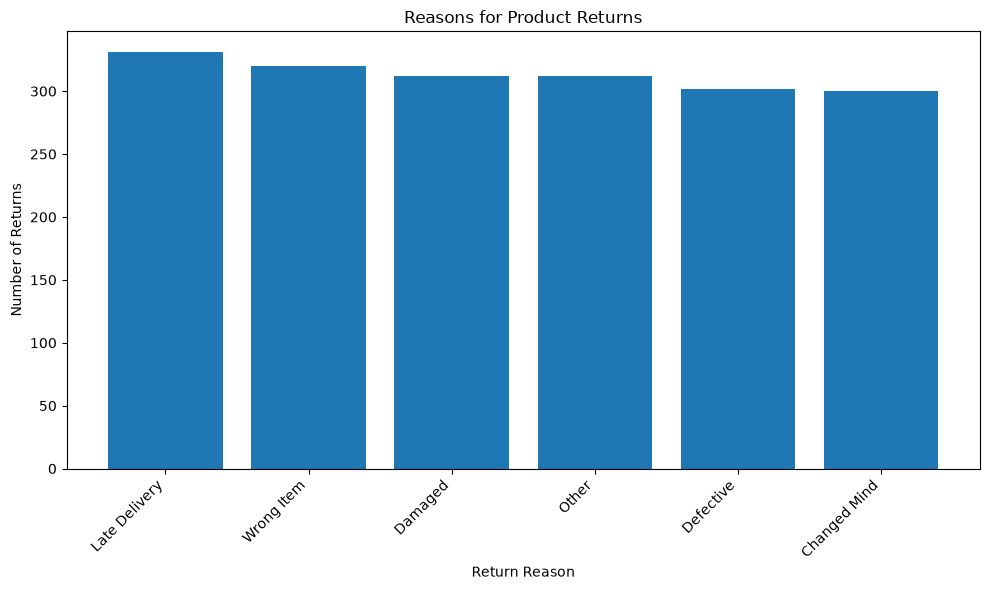

In [29]:
# Return Reasons Graph

plt.figure(figsize=(10, 6))

plt.bar(return_reasons.index, return_reasons.values)

plt.title("Reasons for Product Returns")
plt.xlabel("Return Reason")
plt.ylabel("Number of Returns")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [30]:
rating_counts=df["Customer_Rating"].value_counts().sort_index()
print(rating_counts)

Customer_Rating
1.0     418
2.0     900
3.0    2324
4.0    9230
5.0    5173
Name: count, dtype: int64


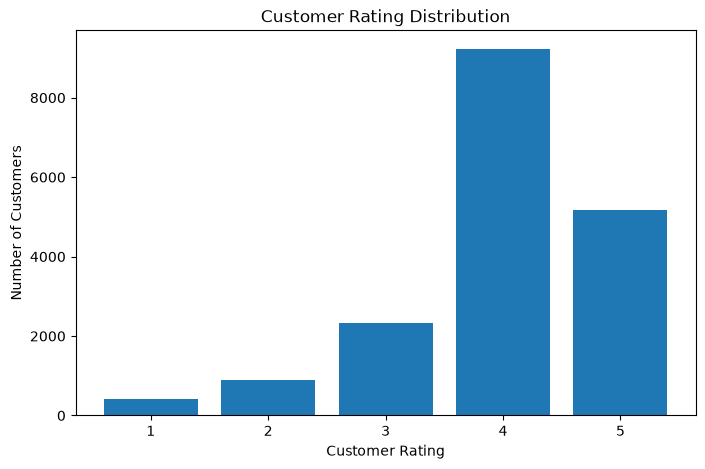

In [31]:
# Customer Rating Distribution

plt.figure(figsize=(8, 5))

plt.bar(rating_counts.index, rating_counts.values)

plt.title("Customer Rating Distribution")
plt.xlabel("Customer Rating")
plt.ylabel("Number of Customers")

plt.xticks([1, 2, 3, 4, 5])

plt.show()

In [32]:
# Calculate average customer rating

average_rating = df["Customer_Rating"].mean()

print("Average Customer Rating:", round(average_rating, 2))

Average Customer Rating: 3.99


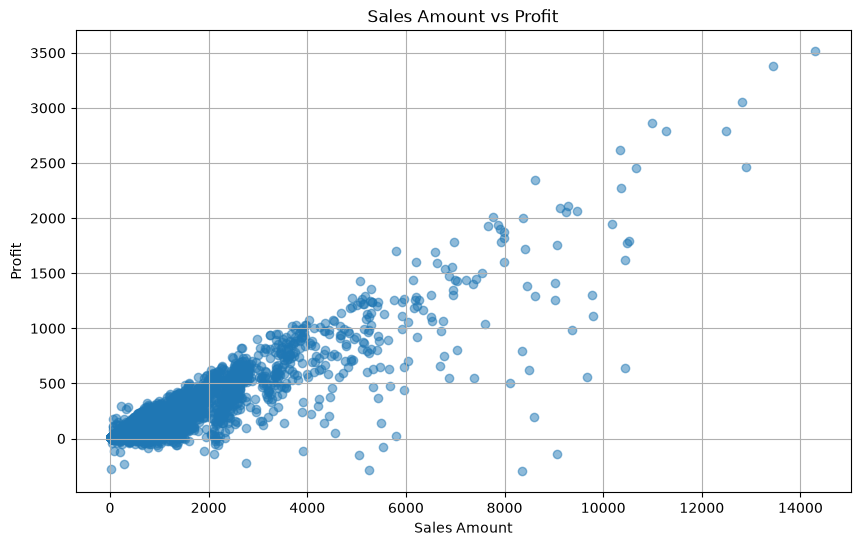

In [33]:
# Sales vs Profit

plt.figure(figsize=(10, 6))

plt.scatter(
    df["Sales_Amount"],
    df["Profit"],
    alpha=0.5
)

plt.title("Sales Amount vs Profit")
plt.xlabel("Sales Amount")
plt.ylabel("Profit")

plt.grid(True)

plt.show()

In [34]:
# Calculate correlation between Sales and Profit

correlation = df["Sales_Amount"].corr(df["Profit"])

print("Correlation between Sales and Profit:", round(correlation, 2))

Correlation between Sales and Profit: 0.92


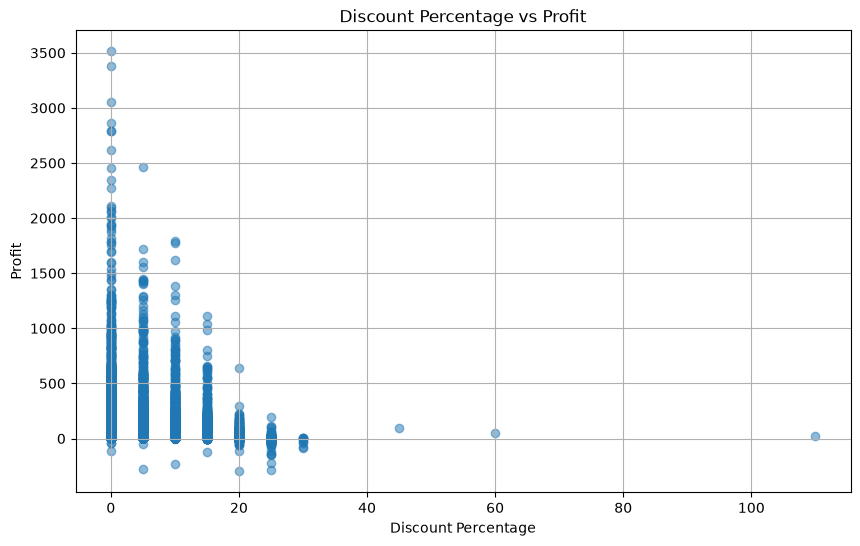

In [35]:
# Discount vs Profit

plt.figure(figsize=(10, 6))

plt.scatter(
    df["Discount_Percentage"],
    df["Profit"],
    alpha=0.5
)

plt.title("Discount Percentage vs Profit")
plt.xlabel("Discount Percentage")
plt.ylabel("Profit")

plt.grid(True)

plt.show()

In [36]:
# Calculate correlation between Discount and Profit

discount_profit_corr = df["Discount_Percentage"].corr(df["Profit"])

print(
    "Correlation between Discount and Profit:",
    round(discount_profit_corr, 2)
)

Correlation between Discount and Profit: -0.19


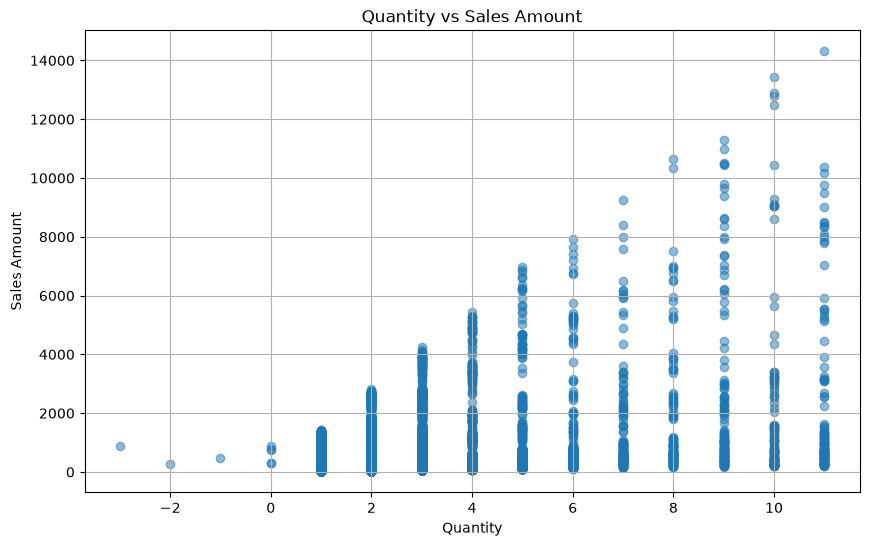

In [37]:
# Quantity vs Sales Amount

plt.figure(figsize=(10, 6))

plt.scatter(
    df["Quantity"],
    df["Sales_Amount"],
    alpha=0.5
)

plt.title("Quantity vs Sales Amount")
plt.xlabel("Quantity")
plt.ylabel("Sales Amount")

plt.grid(True)

plt.show()

In [38]:
# Calculate correlation

quantity_sales_corr = df["Quantity"].corr(df["Sales_Amount"])

print(
    "Correlation between Quantity and Sales Amount:",
    round(quantity_sales_corr, 2)
)

Correlation between Quantity and Sales Amount: 0.43


Customer_Segment
New Customer          488.682514
Premium               474.657207
Consumer              456.874423
Returning Customer    452.051416
Corporate             450.325640
Small Business        448.404123
Name: Sales_Amount, dtype: float64


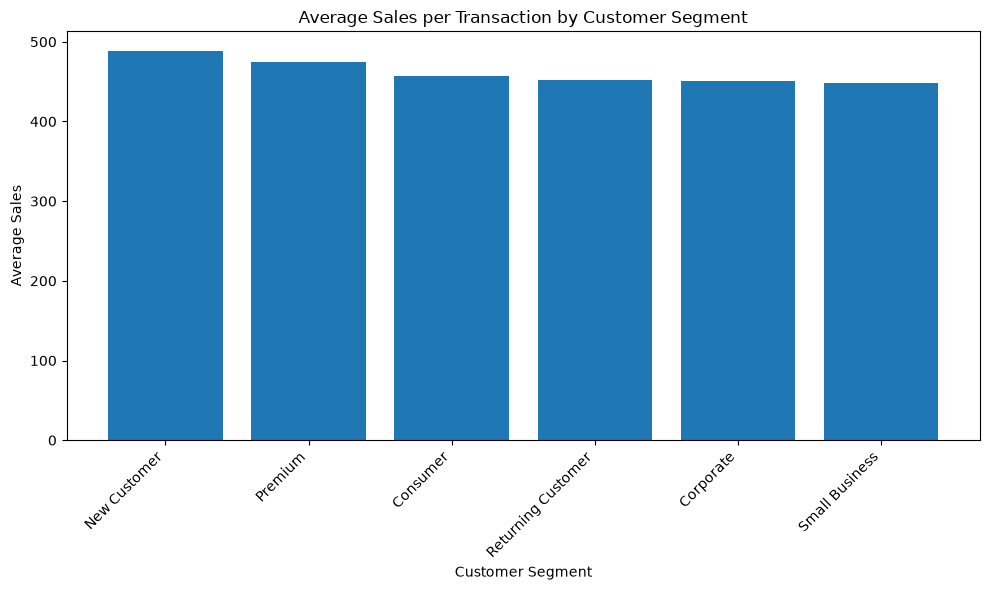

In [39]:
# Average Sales by Customer Segment

avg_sales_segment = (
    df.groupby("Customer_Segment")["Sales_Amount"]
    .mean()
    .sort_values(ascending=False)
)

print(avg_sales_segment)

# Create the graph
plt.figure(figsize=(10, 6))

plt.bar(avg_sales_segment.index, avg_sales_segment.values)

plt.title("Average Sales per Transaction by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Sales")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

Customer_Segment
New Customer          488.682514
Premium               474.657207
Consumer              456.874423
Returning Customer    452.051416
Corporate             450.325640
Small Business        448.404123
Name: Sales_Amount, dtype: float64


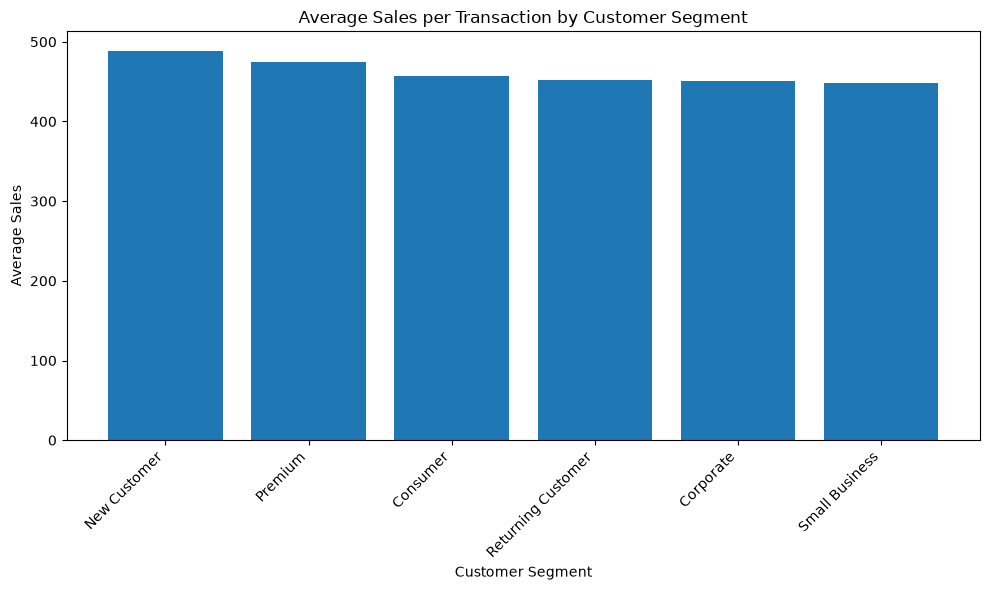

In [40]:
# Average Sales by Customer Segment

avg_sales_segment = (
    df.groupby("Customer_Segment")["Sales_Amount"]
    .mean()
    .sort_values(ascending=False)
)

print(avg_sales_segment)

# Create the graph
plt.figure(figsize=(10, 6))

plt.bar(avg_sales_segment.index, avg_sales_segment.values)

plt.title("Average Sales per Transaction by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Sales")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

Customer_Segment
Premium               98.872855
New Customer          97.540806
Consumer              91.923774
Returning Customer    90.894713
Small Business        90.680793
Corporate             84.023980
Name: Profit, dtype: float64


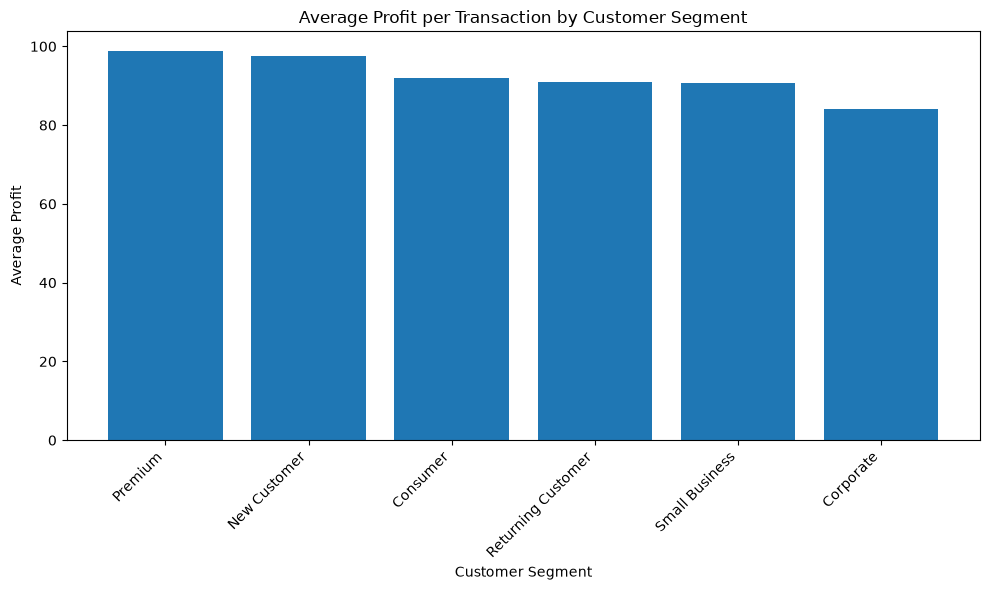

In [41]:
# Average Profit by Customer Segment

avg_profit_segment = (
    df.groupby("Customer_Segment")["Profit"]
    .mean()
    .sort_values(ascending=False)
)

print(avg_profit_segment)

# Create the graph
plt.figure(figsize=(10, 6))

plt.bar(avg_profit_segment.index, avg_profit_segment.values)

plt.title("Average Profit per Transaction by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Profit")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

Customer_Segment
Premium               98.872855
New Customer          97.540806
Consumer              91.923774
Returning Customer    90.894713
Small Business        90.680793
Corporate             84.023980
Name: Profit, dtype: float64


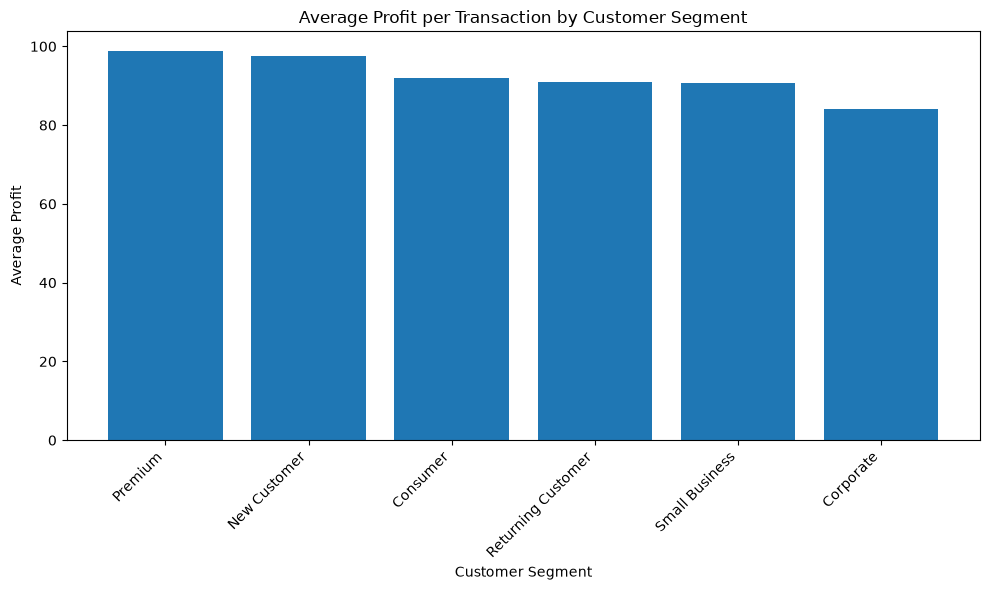

In [42]:
# Average Profit by Customer Segment

avg_profit_segment = (
    df.groupby("Customer_Segment")["Profit"]
    .mean()
    .sort_values(ascending=False)
)

print(avg_profit_segment)

# Create the graph
plt.figure(figsize=(10, 6))

plt.bar(avg_profit_segment.index, avg_profit_segment.values)

plt.title("Average Profit per Transaction by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Profit")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

Region
England                   1330780.58
Northeast                 1009827.87
West                       992442.67
South                      762091.47
Midwest                    742351.80
Île-de-France              727619.06
Ontario                    686905.97
Bavaria                    584156.38
British Columbia           515704.62
New South Wales            513304.60
North Rhine-Westphalia     380499.26
North East                   4026.40
NRW                          1310.35
British columbia             1120.37
Name: Sales_Amount, dtype: float64


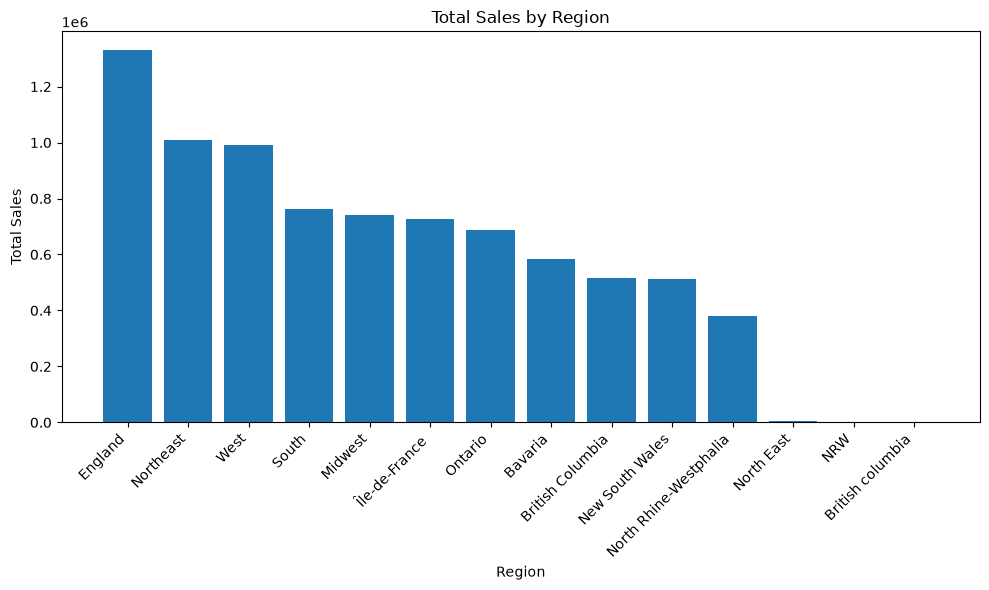

In [43]:
# Sales by Region

sales_by_region = (
    df.groupby("Region")["Sales_Amount"]
    .sum()
    .sort_values(ascending=False)
)

print(sales_by_region)

# Create the graph
plt.figure(figsize=(10, 6))

plt.bar(sales_by_region.index, sales_by_region.values)

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

Region
England                   270472.48
West                      200988.64
Northeast                 200972.82
South                     154985.79
Île-de-France             144987.74
Midwest                   143140.39
Ontario                   136308.03
Bavaria                   114039.00
British Columbia          105365.79
New South Wales           101137.10
North Rhine-Westphalia     75372.93
North East                   977.83
NRW                          373.90
British columbia             265.10
Name: Profit, dtype: float64


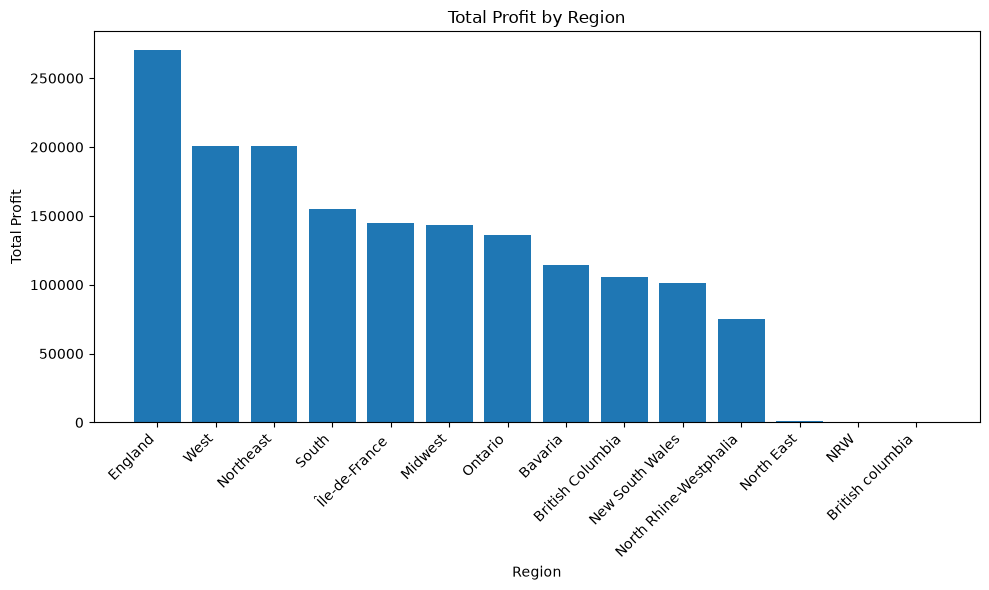

In [44]:
# Profit by Region

profit_by_region = (
    df.groupby("Region")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

print(profit_by_region)

# Create the graph
plt.figure(figsize=(10, 6))

plt.bar(profit_by_region.index, profit_by_region.values)

plt.title("Total Profit by Region")
plt.xlabel("Region")
plt.ylabel("Total Profit")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

Country
United States     3510740.21
United Kingdom    1330780.58
Canada            1203730.96
Germany            965965.99
France             727619.06
Australia          513304.60
Name: Sales_Amount, dtype: float64


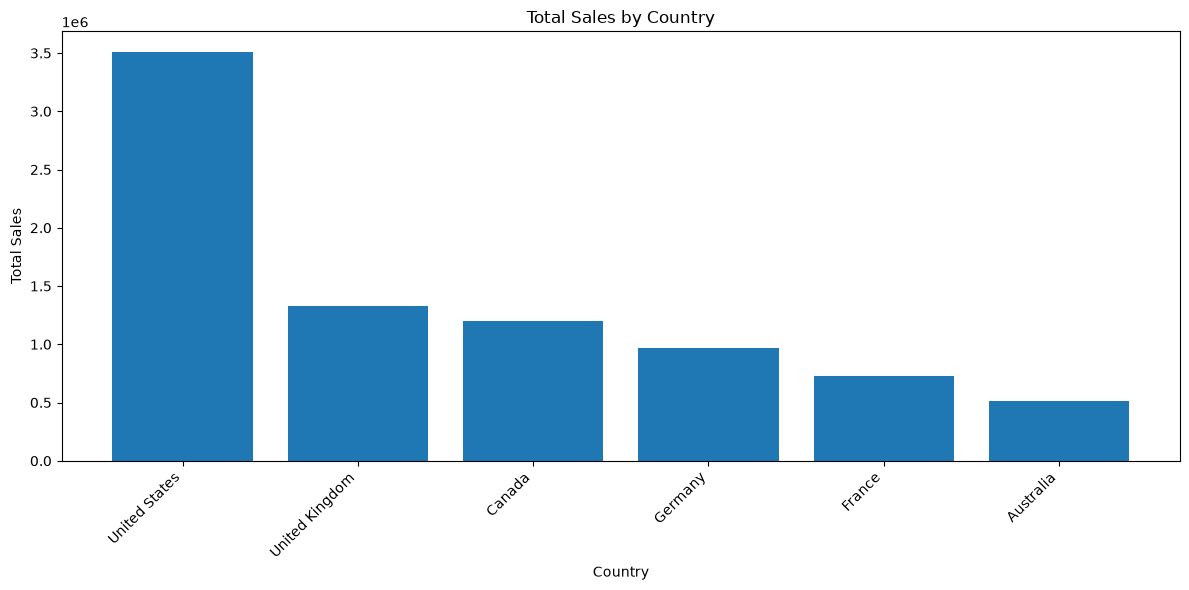

In [45]:
# Sales by Country

sales_by_country = (
    df.groupby("Country")["Sales_Amount"]
    .sum()
    .sort_values(ascending=False)
)

print(sales_by_country)

# Create the graph
plt.figure(figsize=(12, 6))

plt.bar(sales_by_country.index, sales_by_country.values)

plt.title("Total Sales by Country")
plt.xlabel("Country")
plt.ylabel("Total Sales")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

City
New York       1009839.42
Los Angeles     983564.21
London          841516.15
Austin          762091.47
Chicago         742351.80
Paris           727619.06
Toronto         686905.97
Munich          579524.23
Vancouver       516824.99
Sydney          513304.60
Name: Sales_Amount, dtype: float64


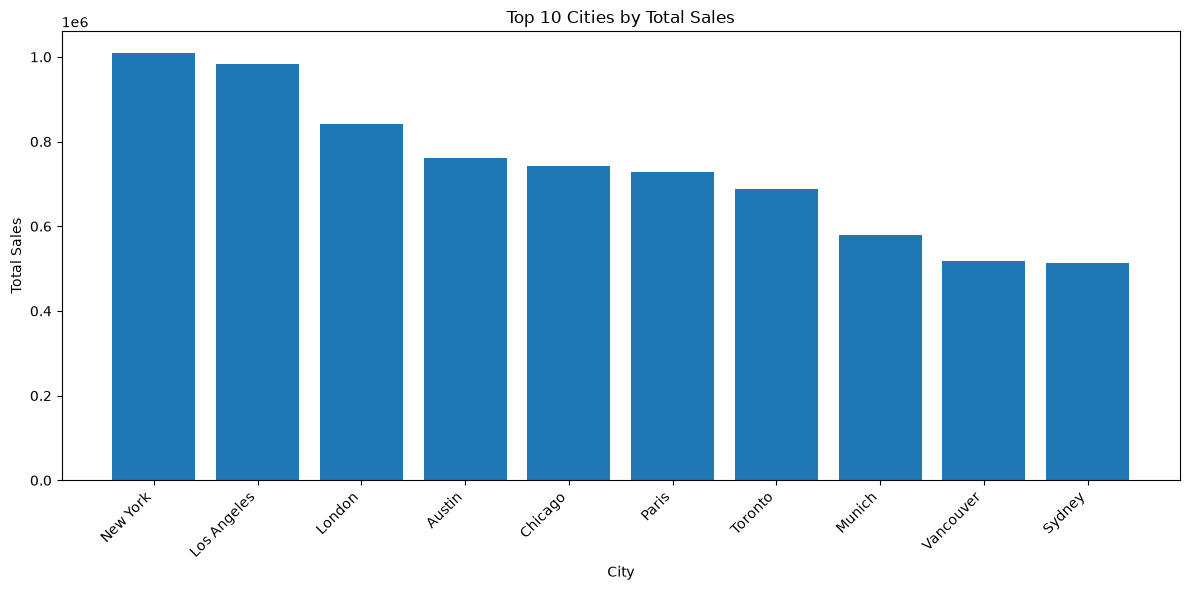

In [46]:
# Top 10 Cities by Sales

top_cities = (
    df.groupby("City")["Sales_Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_cities)

# Create the graph
plt.figure(figsize=(12, 6))

plt.bar(top_cities.index, top_cities.values)

plt.title("Top 10 Cities by Total Sales")
plt.xlabel("City")
plt.ylabel("Total Sales")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [47]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

df["Order_Month"] = df["Order_Date"].dt.month
df["Order_Day"] = df["Order_Date"].dt.day
df["Order_DayOfWeek"] = df["Order_Date"].dt.dayofweek

print("New features created successfully!")

New features created successfully!


In [48]:
df[
    [
        "Order_Date",
        "Order_Month",
        "Order_Day",
        "Order_DayOfWeek"
    ]
].head()

,Order_Date,Order_Month,Order_Day,Order_DayOfWeek
0,2022-10-06,10,6,3
1,2024-06-03,6,3,0
2,2024-12-19,12,19,3
3,2025-10-05,10,5,6
4,2022-09-13,9,13,1


In [49]:
# Select features for the machine learning model

features = [
    "Customer_Age",
    "Quantity",
    "Unit_Price",
    "Discount_Percentage",
    "Cost_Amount",
    "Delivery_Days",
    "Customer_Rating",
    "Inventory_Level",
    "Order_Year",
    "Order_Month",
    "Order_Day",
    "Order_DayOfWeek"
]

X = df[features]
y = df["Sales_Amount"]

print("Number of features:", X.shape[1])
print("Number of records:", X.shape[0])

Number of features: 12
Number of records: 18045


In [50]:
# Check the selected data

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFirst 5 rows of X:")
display(X.head())

print("\nFirst 5 target values:")
display(y.head())

X shape: (18045, 12)
y shape: (18045,)

First 5 rows of X:


,Customer_Age,Quantity,Unit_Price,Discount_Percentage,Cost_Amount,Delivery_Days,Customer_Rating,Inventory_Level,Order_Year,Order_Month,Order_Day,Order_DayOfWeek
0,28.0,2,85.29,5.0,115.61,4.0,4.0,81.0,2022,10,6,3
1,46.0,6,58.85,15.0,237.00,6.0,5.0,123.0,2024,6,3,0
2,42.0,2,43.92,15.0,73.17,4.0,4.0,93.0,2024,12,19,3
3,18.0,11,115.34,15.0,897.91,2.0,4.0,59.0,2025,10,5,6
4,37.0,4,69.71,15.0,164.95,2.0,2.0,56.0,2022,9,13,1



First 5 target values:


0     162.05
1     300.13
2      74.66
3    1078.46
4     237.03
Name: Sales_Amount, dtype: float64

In [52]:
from sklearn.model_selection import train_test_split

In [53]:
# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (14436, 12)
Testing data: (3609, 12)


In [54]:
from sklearn.linear_model import LinearRegression

In [55]:
# Create the Linear Regression model

linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [56]:
# Make predictions on the test data

y_pred = linear_model.predict(X_test)

print("Predictions generated successfully!")
print("First 10 predictions:")
print(y_pred[:10])

Predictions generated successfully!
First 10 predictions:
[ 167.7769106   136.16085058  108.74199698  439.52457464  476.96927625
   73.94382727 1468.61229595  201.87305363  296.85621018   43.24794935]


In [58]:
import numpy as np

In [59]:
# Import evaluation metrics

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Calculate evaluation metrics

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²  :", round(r2, 4))

Linear Regression Results
-------------------------
MAE : 33.68
RMSE: 83.06
R²  : 0.9909


In [60]:
from sklearn.ensemble import RandomForestRegressor

In [61]:
# Create Random Forest model

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [62]:
# Make predictions using Random Forest

rf_pred = rf_model.predict(X_test)

print("Random Forest predictions generated successfully!")
print("First 10 predictions:")
print(rf_pred[:10])

Random Forest predictions generated successfully!
First 10 predictions:
[ 150.0642  119.8542   89.2723  459.4792  449.2352   74.7404 1483.4293
  205.5847  299.6011   58.2065]


In [63]:
# Evaluate Random Forest

rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("--------------------")
print("MAE :", round(rf_mae, 2))
print("RMSE:", round(rf_rmse, 2))
print("R²  :", round(rf_r2, 4))

Random Forest Results
--------------------
MAE : 11.42
RMSE: 54.49
R²  : 0.9961


In [64]:
# Model comparison

models = ["Linear Regression", "Random Forest"]

mae_values = [mae, rf_mae]
rmse_values = [rmse, rf_rmse]
r2_values = [r2, rf_r2]

print("Model Comparison")
print("----------------")
print("Linear Regression - MAE:", round(mae, 2),
      "| RMSE:", round(rmse, 2),
      "| R²:", round(r2, 4))

print("Random Forest     - MAE:", round(rf_mae, 2),
      "| RMSE:", round(rf_rmse, 2),
      "| R²:", round(rf_r2, 4))

Model Comparison
----------------
Linear Regression - MAE: 33.68 | RMSE: 83.06 | R²: 0.9909
Random Forest     - MAE: 11.42 | RMSE: 54.49 | R²: 0.9961


In [65]:
# Model comparison

models = ["Linear Regression", "Random Forest"]

mae_values = [mae, rf_mae]
rmse_values = [rmse, rf_rmse]
r2_values = [r2, rf_r2]

print("Model Comparison")
print("----------------")
print("Linear Regression - MAE:", round(mae, 2),
      "| RMSE:", round(rmse, 2),
      "| R²:", round(r2, 4))

print("Random Forest     - MAE:", round(rf_mae, 2),
      "| RMSE:", round(rf_rmse, 2),
      "| R²:", round(rf_r2, 4))

Model Comparison
----------------
Linear Regression - MAE: 33.68 | RMSE: 83.06 | R²: 0.9909
Random Forest     - MAE: 11.42 | RMSE: 54.49 | R²: 0.9961


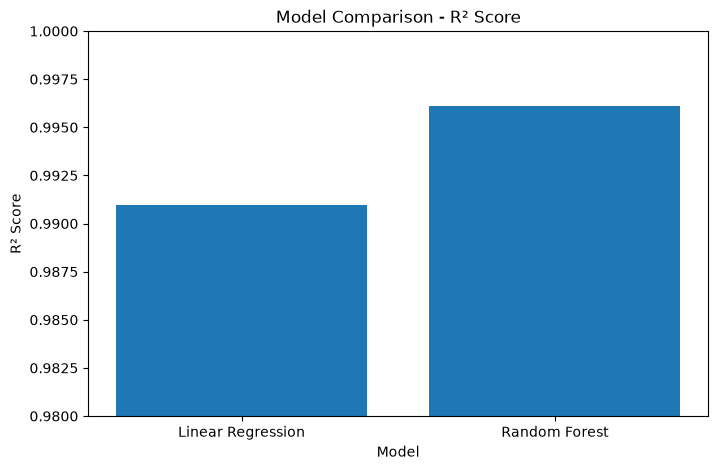

In [66]:
# R² comparison

plt.figure(figsize=(8, 5))

plt.bar(models, r2_values)

plt.title("Model Comparison - R² Score")
plt.xlabel("Model")
plt.ylabel("R² Score")

plt.ylim(0.98, 1.0)

plt.show()

In [67]:
# Get feature importance from Random Forest

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

# Sort from highest to lowest
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

                Feature  Importance
4           Cost_Amount    0.992866
3   Discount_Percentage    0.003700
2            Unit_Price    0.000856
6       Customer_Rating    0.000519
0          Customer_Age    0.000365
9           Order_Month    0.000331
10            Order_Day    0.000326
1              Quantity    0.000284
11      Order_DayOfWeek    0.000280
7       Inventory_Level    0.000254
5         Delivery_Days    0.000132
8            Order_Year    0.000085


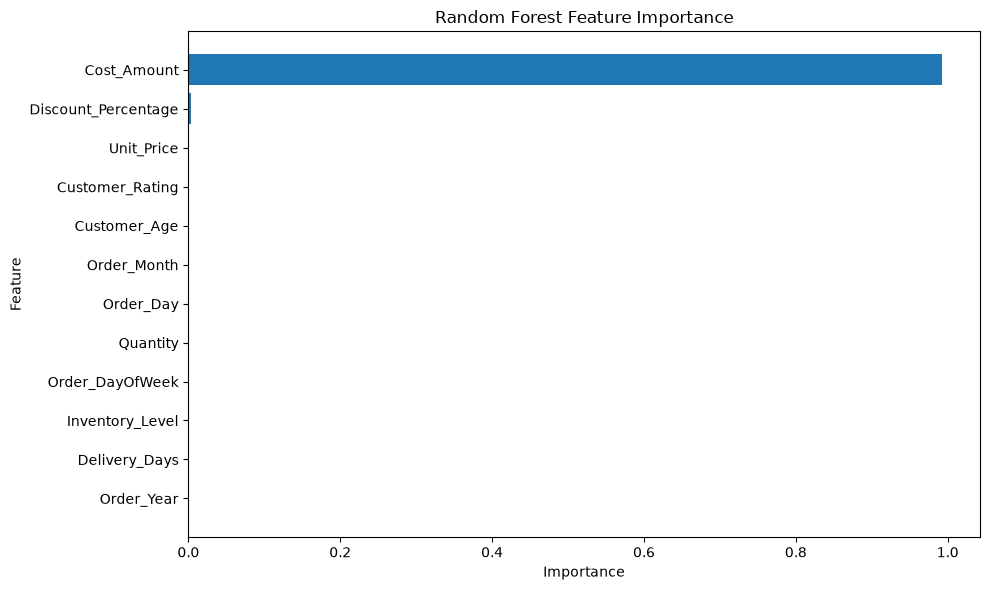

In [68]:
# Plot feature importance

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

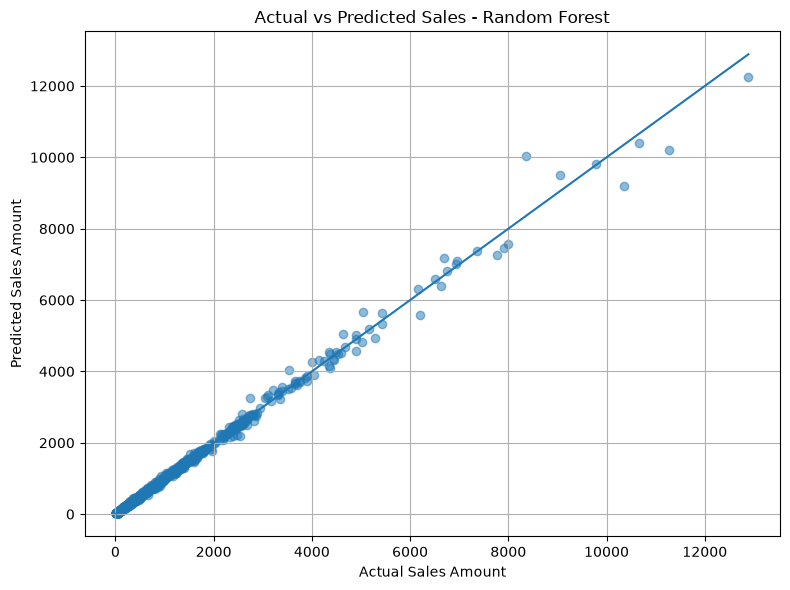

In [69]:
# Actual vs Predicted Sales

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    rf_pred,
    alpha=0.5
)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.title("Actual vs Predicted Sales - Random Forest")
plt.xlabel("Actual Sales Amount")
plt.ylabel("Predicted Sales Amount")

plt.grid(True)
plt.tight_layout()
plt.show()

In [70]:
import joblib

# Save the trained Random Forest model
joblib.dump(rf_model, "sales_prediction_random_forest.pkl")

print("Random Forest model saved successfully!")

Random Forest model saved successfully!


In [71]:
# Save the feature names

joblib.dump(features, "sales_prediction_features.pkl")

print("Feature list saved successfully!")

Feature list saved successfully!


In [72]:
# Create a sample transaction

sample_data = pd.DataFrame({
    "Customer_Age": [30],
    "Quantity": [2],
    "Unit_Price": [100],
    "Discount_Percentage": [5],
    "Cost_Amount": [150],
    "Delivery_Days": [2],
    "Customer_Rating": [4],
    "Inventory_Level": [70],
    "Order_Year": [2025],
    "Order_Month": [9],
    "Order_Day": [22],
    "Order_DayOfWeek": [1]
})

print("Sample transaction created!")
display(sample_data)

Sample transaction created!


,Customer_Age,Quantity,Unit_Price,Discount_Percentage,Cost_Amount,Delivery_Days,Customer_Rating,Inventory_Level,Order_Year,Order_Month,Order_Day,Order_DayOfWeek
0,30,2,100,5,150,2,4,70,2025,9,22,1


In [73]:
# Predict Sales Amount for the sample transaction

sample_prediction = rf_model.predict(sample_data)

print(
    "Predicted Sales Amount:",
    round(sample_prediction[0], 2)
)

Predicted Sales Amount: 210.54


In [74]:
# Final Project Results

print("========== SALES PREDICTION PROJECT ==========")

print("\nDataset:")
print("Total Transactions:", len(df))
print("Total Features Used for ML:", len(features))

print("\nLinear Regression:")
print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²  :", round(r2, 4))

print("\nRandom Forest:")
print("MAE :", round(rf_mae, 2))
print("RMSE:", round(rf_rmse, 2))
print("R²  :", round(rf_r2, 4))

print("\nSample Prediction:")
print("Predicted Sales Amount:", round(sample_prediction[0], 2))

print("\n==============================================")

========== SALES PREDICTION PROJECT ==========

Dataset:
Total Transactions: 18045
Total Features Used for ML: 12

Linear Regression:
MAE : 33.68
RMSE: 83.06
R²  : 0.9909

Random Forest:
MAE : 11.42
RMSE: 54.49
R²  : 0.9961

Sample Prediction:
Predicted Sales Amount: 210.54



In [75]:
# Standardize Product Category names

df["Product_Category"] = df["Product_Category"].str.strip().str.title()

print(df["Product_Category"].value_counts())

Product_Category
Electronics        8209
Office Supplies    4537
Furniture          3311
Appliances         1988
Name: count, dtype: int64


In [76]:
# Standardize Payment Method names

df["Payment_Method"] = (
    df["Payment_Method"]
    .str.strip()
    .str.title()
    .replace({
        "Debitcard": "Debit Card",
        "Paypal": "PayPal",
        "Bank Transfer": "Bank Transfer"
    })
)

print(df["Payment_Method"].value_counts())

Payment_Method
Credit Card      6820
Debit Card       3965
PayPal           2823
Bank Transfer    2160
Apple Pay        1088
Cash             1042
Unknown           147
Name: count, dtype: int64
